In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Reproducibility (score-neutral; stabilizes runs)
np.random.seed(27)
tf.random.set_seed(27)

# Use the canonical Kaggle input root for this competition
DATA_ROOT = "/kaggle/input/aerial-cactus-identification"

print("Listing /kaggle/input:", os.listdir("/kaggle/input")[:20])
print("Using DATA_ROOT:", DATA_ROOT)
print("DATA_ROOT contents:", sorted(os.listdir(DATA_ROOT))[:20])




2026-01-10 22:32:37.900857: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768084357.915073      11 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768084357.919398      11 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-10 22:32:37.938521: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Listing /kaggle/input: ['sample_submission.csv', 'description.md', 'test.zip', 'train.csv', 'sample_submission.csv.zip', 'test', 'train.zip', 'aerial-cactus-identification', 'train', 'train.csv.zip']
Using DATA_ROOT: /kaggle/input/aerial-cactus-identification
DATA_ROOT contents: ['aerial-cactus-identification', 'description.md', 'sample_submission.csv', 'sample_submission.csv.zip', 'test', 'test.zip', 'train', 'train.csv', 'train.csv.zip', 'train.zip']


In [2]:
def read_pix(jpg_dir):
    # Fix: ensure deterministic ordering so image arrays align with ids
    filenames = sorted(glob.glob(os.path.join(jpg_dir, "*.jpg")))
    img_array = np.zeros((len(filenames), 32, 32, 3), dtype=np.uint8)
    img_index = []
    for idx, filename in enumerate(filenames):
        im_tmp = matplotlib.image.imread(filename)
        # imread may return float32 [0,1] or uint8 [0,255]
        if im_tmp.dtype != np.uint8:
            im_tmp = (im_tmp * 255.0).astype(np.uint8)
        img_array[idx] = im_tmp[:, :, :3]
        img_index.append(os.path.basename(filename))
    return img_array, img_index


def prepare_data(img_array, img_index, train_response):
    y_train_series, y_test_series = train_test_split(
        train_response, shuffle=True, random_state=12
    )
    y_train = y_train_series.values[:, np.newaxis]
    y_test = y_test_series.values[:, np.newaxis]

    # Fix: build mapping instead of O(n^2) index lookups
    pos = {fn: i for i, fn in enumerate(img_index)}
    train_index = [pos[idx] for idx in y_train_series.index]
    test_index = [pos[idx] for idx in y_test_series.index]

    x_train = img_array[train_index, :, :, :]
    x_test = img_array[test_index, :, :, :]
    return x_train, y_train, x_test, y_test, y_train_series, y_test_series


def simple_oversample(x, y, oversample_class, oversample_factor=3):
    new_x = x.copy()
    new_y = y.copy()
    oversample_mask = np.ravel(y == oversample_class)
    oversample_x = x[oversample_mask, :, :, :]
    oversample_y = y[oversample_mask, :]
    for _ in range(oversample_factor):
        new_x = np.concatenate([new_x, oversample_x], axis=0)
        new_y = np.concatenate([new_y, oversample_y], axis=0)
    return new_x, new_y




In [3]:
# Fix: correct file paths for Kaggle environment
train_labels = pd.read_csv(os.path.join(DATA_ROOT, "train.csv"))
sample_submission = pd.read_csv(os.path.join(DATA_ROOT, "sample_submission.csv"))

train_dir = os.path.join(DATA_ROOT, "train")
test_dir = os.path.join(DATA_ROOT, "test")

train_img_array, train_img_index = read_pix(train_dir)
test_img_array, test_img_index = read_pix(test_dir)

train_response = train_labels["has_cactus"]
train_response.index = train_labels["id"]

# Align to the read image ordering (critical correctness)
train_response = train_response.loc[train_img_index]

print("Loaded train images:", train_img_array.shape, "labels:", train_response.shape)
print("Loaded test images:", test_img_array.shape)
print(sample_submission.head(2))



Loaded train images: (14175, 32, 32, 3) labels: (14175,)
Loaded test images: (3325, 32, 32, 3)
                                     id  has_cactus
0  09034a34de0e2015a8a28dfe18f423f6.jpg         0.5
1  134f04305c795d6d202502c2ce3578f3.jpg         0.5


In [4]:
print("Image Labels")
print(train_labels.head(2))
print("\nImage Labels (Series)")
print(train_response.head(2))
print("\nSubmission Example")
print(sample_submission.head(2))



Image Labels
                                     id  has_cactus
0  2de8f189f1dce439766637e75df0ee27.jpg           1
1  36704d250f236238e7f996812c48235d.jpg           1

Image Labels (Series)
id
0004be2cfeaba1c0361d39e2b000257b.jpg    1
000c8a36845c0208e833c79c1bffedd1.jpg    1
Name: has_cactus, dtype: int64

Submission Example
                                     id  has_cactus
0  09034a34de0e2015a8a28dfe18f423f6.jpg         0.5
1  134f04305c795d6d202502c2ce3578f3.jpg         0.5


Some examples


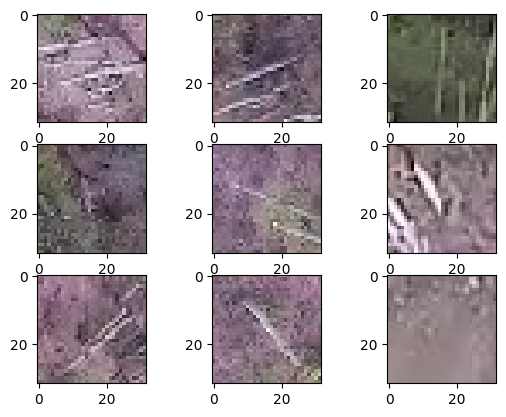

Image Labels
id
5ac17f342ffd4014e0c2b372521b07a3.jpg    1
41890d2aa3c94058e2f30e7a93943a36.jpg    1
4452b51c105a1f5e9a106995e945a4dd.jpg    1
5567ec5233b7450511fc545cce5fde01.jpg    1
f56915e7c5d4512788fc238a79744f9b.jpg    1
7f61cb6df9c7b02e5b97e45a44060d70.jpg    1
4a390fc13c1f7bdbc0c61308326a6a3f.jpg    1
c751500650247d1a1ac530f34cdb855f.jpg    1
120a0d3b7e54ee6136af47e11b44db37.jpg    0
Name: has_cactus, dtype: int64


In [5]:
# Optional visualization (kept, but safe to run headless)
print("Some examples")
inspect = np.random.randint(low=0, high=train_img_array.shape[0], size=9)
for i in range(9):
    pic_id = inspect[i]
    plt.subplot(330 + 1 + i)
    plt.imshow(train_img_array[pic_id].astype(int))
plt.show()

print("Image Labels")
print(train_response.loc[np.array(train_img_index)[inspect]])



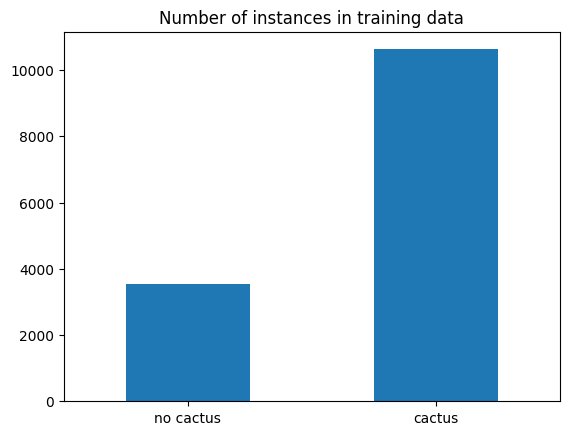

Ratio (cactus vs. no cactus): 3.00


In [6]:
count_classes = pd.crosstab(train_response, columns="count")
count_classes.index = ["no cactus", "cactus"]
count_classes.plot(kind="bar", legend=False)
plt.xticks(rotation=0)
plt.title("Number of instances in training data")
plt.show()
ratio = count_classes.loc["cactus", "count"] / count_classes.loc["no cactus", "count"]
print("Ratio (cactus vs. no cactus): {:.2f}".format(ratio))



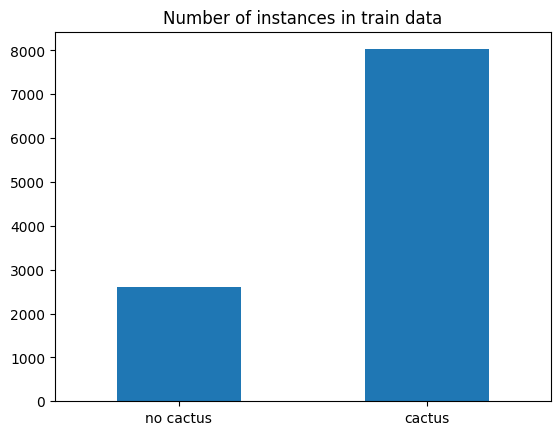

Ratio (cactus vs. no cactus): 3.08


In [7]:
x_train, y_train, x_test, y_test, y_train_series, y_test_series = prepare_data(
    train_img_array, train_img_index, train_response
)

count_classes_train = pd.crosstab(y_train_series, columns="count")
count_classes_train.index = ["no cactus", "cactus"]
count_classes_train.plot(kind="bar", legend=None)
plt.xticks(rotation=0)
plt.title("Number of instances in train data")
plt.show()
ratio = (
    count_classes_train.loc["cactus", "count"]
    / count_classes_train.loc["no cactus", "count"]
)
print("Ratio (cactus vs. no cactus): {:.2f}".format(ratio))



Some images from the training set


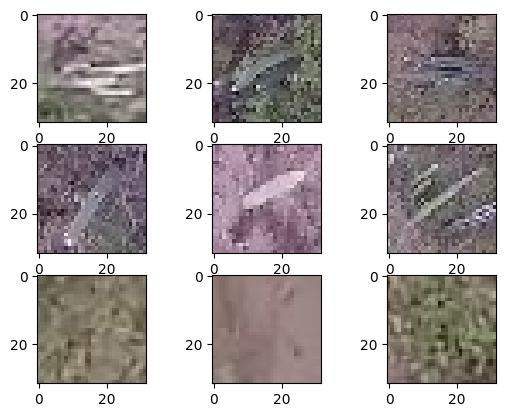

Accompanying labels
[1 1 1 1 1 1 0 0 0]


In [8]:
print("Some images from the training set")
inspect = np.random.randint(low=0, high=y_train.shape[0], size=9)
for i in range(9):
    pic_id = inspect[i]
    plt.subplot(330 + 1 + i)
    plt.imshow(x_train[pic_id].astype(int))
plt.show()

print("Accompanying labels")
print(y_train[inspect].ravel())



In [9]:
batch_size = 128
num_classes = 2
epochs = 12

datagen = ImageDataGenerator(
    rotation_range=360,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode="nearest",
)

# Recreate split exactly as original flow
x_train, y_train, x_test, y_test, y_train_series, y_test_series = prepare_data(
    train_img_array, train_img_index, train_response
)
x_train, y_train = simple_oversample(
    x_train, y_train, oversample_class=0, oversample_factor=2
)
x_test, y_test = simple_oversample(
    x_test, y_test, oversample_class=0, oversample_factor=2
)

print("Number of 'no cactus' samples in y_train: {}".format(int((y_train == 0).sum())))
print("Number of 'cactus' samples in y_train: {}".format(int((y_train == 1).sum())))



Number of 'no cactus' samples in y_train: 7815
Number of 'cactus' samples in y_train: 8026


Some images from the oversampled training set


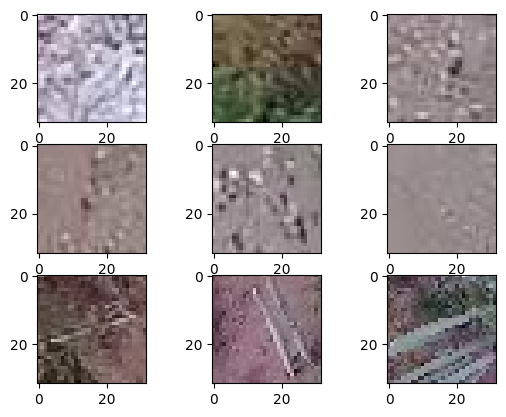

Accompanying labels
[0 0 0 0 0 0 1 1 1]


In [10]:
print("Some images from the oversampled training set")
inspect = np.random.randint(low=0, high=y_train.shape[0], size=9)
for i in range(9):
    pic_id = inspect[i]
    plt.subplot(330 + 1 + i)
    plt.imshow(x_train[pic_id].astype(int))
plt.show()

print("Accompanying labels")
print(y_train[inspect].ravel())



In [11]:
# Normalize inputs
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

train_generator = datagen.flow(
    x_train, y_train, batch_size=batch_size, shuffle=True, seed=27
)
test_datagen = ImageDataGenerator()
validation_generator = test_datagen.flow(
    x_test, y_test, batch_size=batch_size, shuffle=False
)




In [12]:
def baseline_model():
    model = Sequential()
    model.add(Conv2D(32, (5, 5), input_shape=(32, 32, 3), activation="relu"))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.2))
    model.add(Flatten())
    model.add(Dense(128, activation="relu"))
    model.add(Dense(1, activation="sigmoid"))
    # Fix: Keras 3 uses learning_rate instead of lr
    model.compile(
        loss="binary_crossentropy",
        optimizer=RMSprop(learning_rate=1e-4),
        metrics=["accuracy"],
    )
    return model




In [13]:
def elaborate_model():
    model = Sequential()
    model.add(Conv2D(32, (5, 5), input_shape=(32, 32, 3), activation="relu"))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Conv2D(64, (5, 5), activation="relu"))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Conv2D(64, (3, 3), activation="relu"))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Flatten())
    model.add(Dropout(0.2))
    model.add(Dense(128, activation="relu"))
    model.add(Dense(1, activation="sigmoid"))
    model.compile(
        loss="binary_crossentropy",
        optimizer=RMSprop(learning_rate=1e-4),
        metrics=["accuracy"],
    )
    return model




In [14]:
model = elaborate_model()

# Fix: fit_generator deprecated -> fit; keep same semantics
hist = model.fit(
    train_generator,
    steps_per_epoch=int(np.ceil(x_train.shape[0] / 32)),
    epochs=20,
    validation_data=(x_test, y_test),
    verbose=2,
)

scores = model.evaluate(x_test, y_test, verbose=0)
print("CNN error: {:.2f}".format(100 - scores[1] * 100))



/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-01-10 22:32:49.359846: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1768084369.360690      11 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46866 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:45:00.0, compute capability: 8.6


Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1768084370.560010      62 service.cc:148] XLA service 0x7f89f8025310 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1768084370.560054      62 service.cc:156]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
2026-01-10 22:32:50.584408: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1768084370.683900      62 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1768084371.855197      62 device_compiler.h:188] Compile

496/496 - 8s - 16ms/step - accuracy: 0.7065 - loss: 0.6171 - val_accuracy: 0.8510 - val_loss: 0.4427
Epoch 2/20
496/496 - 5s - 10ms/step - accuracy: 0.8542 - loss: 0.4026 - val_accuracy: 0.8930 - val_loss: 0.2877
Epoch 3/20
496/496 - 5s - 10ms/step - accuracy: 0.8680 - loss: 0.3361 - val_accuracy: 0.8515 - val_loss: 0.3908
Epoch 4/20
496/496 - 5s - 9ms/step - accuracy: 0.8683 - loss: 0.3248 - val_accuracy: 0.7883 - val_loss: 0.5415
Epoch 5/20
496/496 - 5s - 9ms/step - accuracy: 0.8738 - loss: 0.3114 - val_accuracy: 0.8821 - val_loss: 0.3026
Epoch 6/20
496/496 - 5s - 10ms/step - accuracy: 0.8757 - loss: 0.3061 - val_accuracy: 0.8394 - val_loss: 0.4147
Epoch 7/20
496/496 - 5s - 10ms/step - accuracy: 0.8790 - loss: 0.2995 - val_accuracy: 0.8583 - val_loss: 0.3587
Epoch 8/20
496/496 - 4s - 9ms/step - accuracy: 0.8802 - loss: 0.2962 - val_accuracy: 0.8430 - val_loss: 0.3936
Epoch 9/20
496/496 - 4s - 9ms/step - accuracy: 0.8823 - loss: 0.2906 - val_accuracy: 0.8620 - val_loss: 0.3403
Epoch 1

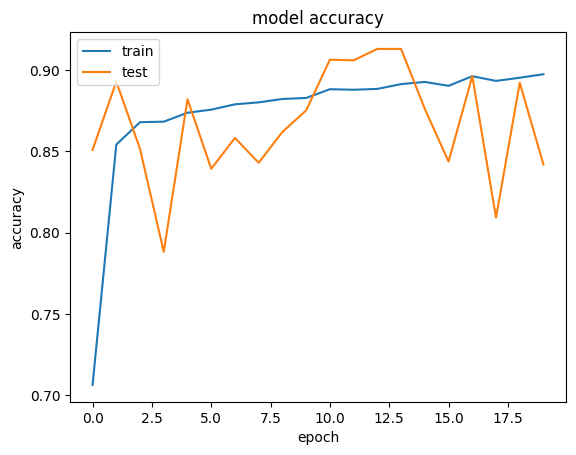

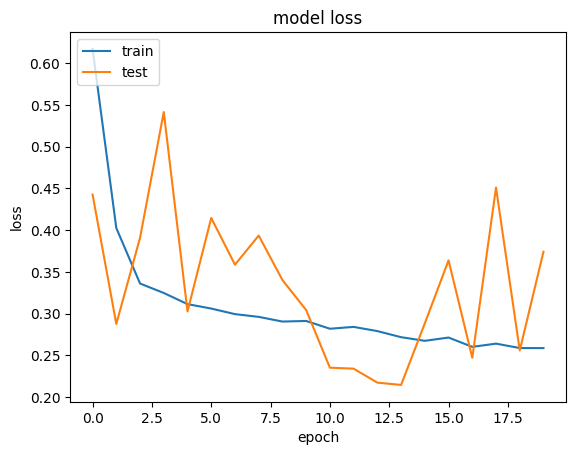

In [15]:
# Fix: history keys are 'accuracy'/'val_accuracy' in tf.keras
plt.plot(hist.history.get("accuracy", []))
plt.plot(hist.history.get("val_accuracy", []))
plt.title("model accuracy")
plt.ylabel("accuracy")
plt.xlabel("epoch")
plt.legend(["train", "test"], loc="upper left")
plt.show()

plt.plot(hist.history.get("loss", []))
plt.plot(hist.history.get("val_loss", []))
plt.title("model loss")
plt.ylabel("loss")
plt.xlabel("epoch")
plt.legend(["train", "test"], loc="upper left")
plt.show()



In [16]:
# Fix: predict_proba not supported; use predict. Also ensure test normalization float32.
probability = model.predict(
    test_img_array.astype("float32") / 255.0, batch_size=256, verbose=0
)

res = pd.DataFrame(
    {
        "id": test_img_index,
        "has_cactus": probability.ravel(),
    }
)

# Fix: enforce same id order as sample_submission (safe, score-neutral; avoids misalignment)
res = sample_submission[["id"]].merge(res, on="id", how="left")
res["has_cactus"] = res["has_cactus"].fillna(res["has_cactus"].mean())

res.to_csv("submission.csv", index=False)
print("Wrote submission.csv with shape:", res.shape)
print(res.head())



Wrote submission.csv with shape: (3325, 2)
                                     id  has_cactus
0  09034a34de0e2015a8a28dfe18f423f6.jpg    0.835111
1  134f04305c795d6d202502c2ce3578f3.jpg    0.996515
2  41fad8d145e6c41868ce3617e30a2545.jpg    0.997911
3  35f8a11352c8d41b6231bb33d8d09f7e.jpg    0.997717
4  b77dc902b035887cbbc01920ce0e3151.jpg    0.998535


In [17]:
# Sanity checks for submission format
assert list(res.columns) == ["id", "has_cactus"]
assert res.shape[0] == sample_submission.shape[0]
assert res["has_cactus"].between(0.0, 1.0).all()
print("Submission format looks valid.")

Submission format looks valid.
